# Machine Learning-Based Phishing Website Detection

## 1. Project Setup

## 2. Dataset Loading

## 3. Data Understanding and EDA

## 4. Data Cleaning and Feature Handling

## 5. Model Training

## 6. Model Evaluation and Comparison

## 7. Final Model Saving

## 1. Project Setup

In [ ]:
# Project Setup

# Importing the main libraries required for data handling, visualisation, model training, and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")


Libraries imported successfully.


In [1]:
# Project Setup

# Importing the main libraries required for data handling, visualisation, model training, and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Dataset Loading

In [3]:
# Dataset Loading

# Upload dataset file
from google.colab import files

uploaded = files.upload()

Saving PhiUSIIL_Phishing_URL_Dataset.csv to PhiUSIIL_Phishing_URL_Dataset.csv


In [4]:
# Read the uploaded file

import io

# Get the uploaded file name automatically
file_name = list(uploaded.keys())[0]

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
df.head()

Dataset loaded successfully.
Dataset shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [5]:
# Display all column names in the dataset

df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [6]:
# Display basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [7]:
# Check the last few columns to find the target variable

df.tail()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
235790,660997.txt,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,...,1,0,1,51,7,21,187,2,191,1
235791,77185.txt,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,...,1,0,0,50,1,7,88,0,31,1
235792,622132.txt,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,...,0,0,1,27,10,30,58,2,67,1
235793,7503962.txt,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,...,0,0,0,0,0,3,0,0,0,0
235794,384822.txt,https://www.alternativefinland.com,33,www.alternativefinland.com,26,0,com,100.000000,1.000000,0.522907,...,0,0,1,21,6,18,256,0,261,1


In [8]:
# Check target column values

print("Target column value counts:")
print(df['label'].value_counts())

print("\nTarget column percentage distribution:")
print(df['label'].value_counts(normalize=True) * 100)

Target column value counts:
label
1    134850
0    100945
Name: count, dtype: int64

Target column percentage distribution:
label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


In [9]:
# Check missing values and duplicate rows

print("Total missing values in the dataset:")
print(df.isnull().sum().sum())

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nTotal duplicate rows:")
print(df.duplicated().sum())

Total missing values in the dataset:
0

Missing values by column:
FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title 

The dataset contains 235,795 website records and 56 columns. The target variable is `label`, where 1 represents legitimate websites and 0 represents phishing websites. The class distribution shows that 57.19% of the records are legitimate and 42.81% are phishing. No missing values were found in the dataset, so missing-value imputation was not required.

## 3. Data Understanding and EDA

This section explores the structure of the dataset, the distribution of the target variable, and the behaviour of selected features. The purpose of EDA is to understand the data before model training and to identify any issues that may affect model performance.

Class distribution:
label
1    134850
0    100945
Name: count, dtype: int64


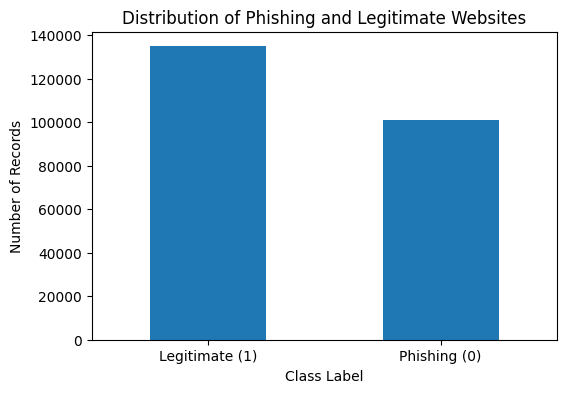

In [10]:
# Class distribution of the target variable

label_counts = df['label'].value_counts()

print("Class distribution:")
print(label_counts)

plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.title("Distribution of Phishing and Legitimate Websites")
plt.xlabel("Class Label")
plt.ylabel("Number of Records")
plt.xticks(ticks=[0, 1], labels=["Legitimate (1)", "Phishing (0)"], rotation=0)
plt.show()

The class distribution shows that the dataset contains more legitimate websites than phishing websites. There are 134,850 legitimate records and 100,945 phishing records. Although the dataset is not perfectly balanced, both classes have a large number of samples, which makes the dataset suitable for supervised classification. This also means that evaluation should not rely only on accuracy; precision, recall and F1-score should also be considered.

In [11]:
# Summary statistics for numerical columns

df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [12]:
# Check numerical and categorical columns

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Number of numerical columns:", len(numeric_columns))
print("Numerical columns:")
print(list(numeric_columns))

print("\nNumber of categorical columns:", len(categorical_columns))
print("Categorical columns:")
print(list(categorical_columns))

Number of numerical columns: 51
Numerical columns:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

Number of categorical columns: 5
Categorical columns:
['FILENAME', 'URL', 

In [13]:
# Check correlation of numerical features with the target label

correlation_with_label = df[numeric_columns].corr()['label'].sort_values(ascending=False)

print("Correlation of numerical features with the target label:")
print(correlation_with_label)

Correlation of numerical features with the target label:
label                         1.000000
URLSimilarityIndex            0.860358
HasSocialNet                  0.784255
HasCopyrightInfo              0.743358
HasDescription                0.690232
IsHTTPS                       0.609132
DomainTitleMatchScore         0.584905
HasSubmitButton               0.578561
IsResponsive                  0.548608
URLTitleMatchScore            0.539419
HasHiddenFields               0.507731
HasFavicon                    0.493711
URLCharProb                   0.469749
CharContinuationRate          0.467735
HasTitle                      0.459725
Robots                        0.392620
NoOfJS                        0.373500
Pay                           0.359747
NoOfSelfRef                   0.316211
NoOfImage                     0.274658
LineOfCode                    0.272257
NoOfExternalRef               0.258627
NoOfiFrame                    0.225822
Bank                          0.188959
HasExte

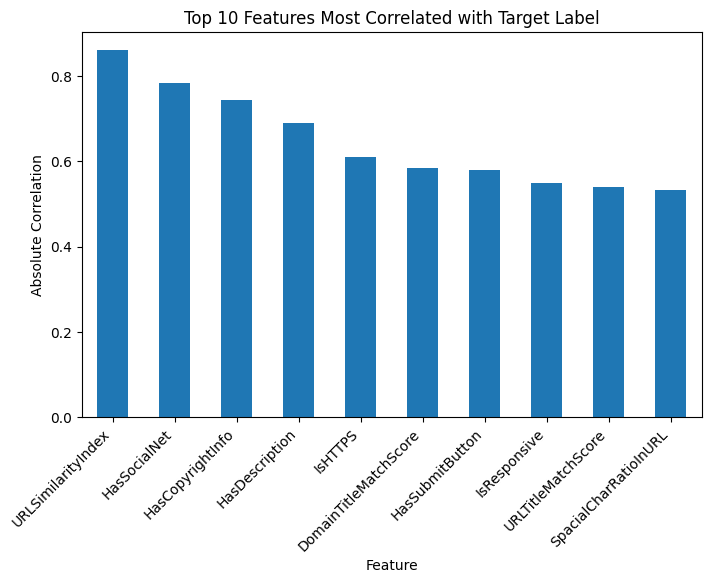

In [14]:
# Plot top correlated features with the target label

correlation_without_label = correlation_with_label.drop('label')

top_correlations = correlation_without_label.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_correlations.plot(kind='bar')
plt.title("Top 10 Features Most Correlated with Target Label")
plt.xlabel("Feature")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45, ha='right')
plt.show()

The correlation analysis shows that several website and URL-related features are strongly associated with the target variable. `URLSimilarityIndex` has the highest correlation with the class label, followed by features such as `HasSocialNet`, `HasCopyrightInfo`, `HasDescription`, and `IsHTTPS`. These results suggest that both URL structure and webpage-related characteristics may support phishing website classification. However, correlation does not prove causation; it only indicates statistical association within this dataset.

In [15]:
# Display signed correlation values for the top correlated features

top_feature_names = top_correlations.index

print("Signed correlation values for top features:")
print(correlation_with_label[top_feature_names])

Signed correlation values for top features:
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL   -0.533537
Name: label, dtype: float64


## 4. Data Cleaning and Feature Handling

This section prepares the dataset for machine learning. The dataset is checked for duplicate records, non-numeric columns are separated, and the target variable is defined. A train-test split is then applied so that the model can be evaluated on unseen data. To keep the final Streamlit application practical, a selected group of important numerical features is used for model training.

In [16]:
# Check duplicate rows again

duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


In [17]:
# Remove duplicate rows if any exist

df_cleaned = df.drop_duplicates()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_cleaned.shape)

Original dataset shape: (235795, 56)
Cleaned dataset shape: (235795, 56)


In [18]:
# Data Cleaning and Feature Handling

# Select only numerical columns for model training
# Text columns such as URL, Domain, TLD, Title and FILENAME are excluded at this stage

numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64']).copy()

print("Numerical dataset shape:", numeric_df.shape)

# Define input features and target variable
X = numeric_df.drop('label', axis=1)
y = numeric_df['label']

print("Input feature shape:", X.shape)
print("Target variable shape:", y.shape)

Numerical dataset shape: (235795, 51)
Input feature shape: (235795, 50)
Target variable shape: (235795,)


In [19]:
# Split the dataset into training and testing sets

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train_full.shape)
print("Testing feature shape:", X_test_full.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (188636, 50)
Testing feature shape: (47159, 50)
Training target shape: (188636,)
Testing target shape: (47159,)


In [20]:
# Select top 10 features using correlation from the training set only

train_data_for_corr = X_train_full.copy()
train_data_for_corr['label'] = y_train.values

train_correlation = train_data_for_corr.corr()['label'].drop('label')

selected_features = train_correlation.abs().sort_values(ascending=False).head(10).index.tolist()

print("Selected features for model training:")
print(selected_features)

Selected features for model training:
['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton', 'IsResponsive', 'URLTitleMatchScore', 'SpacialCharRatioInURL']


In [21]:
# Create final training and testing sets using selected features

X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

print("Final training set shape:", X_train.shape)
print("Final testing set shape:", X_test.shape)

Final training set shape: (188636, 10)
Final testing set shape: (47159, 10)


In [22]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## 5. Model Training

This section trains different machine learning models using the prepared dataset. Three supervised classification models are used: Logistic Regression, Decision Tree, and Random Forest. These models are selected because they provide a useful comparison between a linear model, a simple tree-based model, and an ensemble-based model. The trained models will later be compared using evaluation metrics.

In [23]:
# Model Training

import time

# Define the models to be trained
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

trained_models = {}
predictions = {}
training_times = {}

# Train each model
for model_name, model in models.items():
    print(f"Training {model_name}...")

    start_time = time.time()

    # Logistic Regression uses scaled data
    if model_name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Tree-based models use the original selected features
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    end_time = time.time()

    trained_models[model_name] = model
    predictions[model_name] = y_pred
    training_times[model_name] = end_time - start_time

    print(f"{model_name} trained successfully.")
    print(f"Training time: {training_times[model_name]:.2f} seconds\n")

Training Logistic Regression...
Logistic Regression trained successfully.
Training time: 0.59 seconds

Training Decision Tree...
Decision Tree trained successfully.
Training time: 0.17 seconds

Training Random Forest...
Random Forest trained successfully.
Training time: 5.99 seconds



## 6. Model Evaluation and Comparison

This section evaluates the trained models using accuracy, precision, recall, F1-score, and confusion matrix. These metrics are used because accuracy alone may not fully explain classification performance, especially when the classes are not perfectly balanced. The final model is selected based on both predictive performance and practical suitability.

In [24]:
# Model Evaluation and Comparison

evaluation_results = []

for model_name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=0)
    recall = recall_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred, pos_label=0)

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision (Phishing)": precision,
        "Recall (Phishing)": recall,
        "F1-score (Phishing)": f1,
        "Training Time (seconds)": training_times[model_name]
    })

results_df = pd.DataFrame(evaluation_results)

# Round values for easier reading
results_df_rounded = results_df.copy()
results_df_rounded[["Accuracy", "Precision (Phishing)", "Recall (Phishing)", "F1-score (Phishing)", "Training Time (seconds)"]] = results_df_rounded[["Accuracy", "Precision (Phishing)", "Recall (Phishing)", "F1-score (Phishing)", "Training Time (seconds)"]].round(4)

results_df_rounded

,Model,Accuracy,Precision (Phishing),Recall (Phishing),F1-score (Phishing),Training Time (seconds)
0,Logistic Regression,0.9996,1.0000,0.9991,0.9996,0.5931
1,Decision Tree,0.9997,0.9999,0.9995,0.9997,0.1721
2,Random Forest,0.9997,1.0000,0.9994,0.9997,5.9898


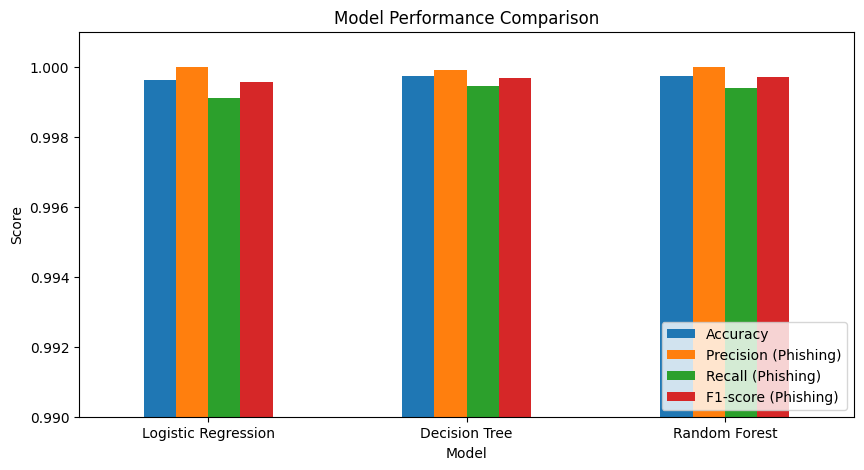

In [25]:
# Model performance comparison chart

metrics_to_plot = ["Accuracy", "Precision (Phishing)", "Recall (Phishing)", "F1-score (Phishing)"]

results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", figsize=(10, 5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.99, 1.001)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

Confusion Matrix for Decision Tree
[[20178    11]
 [    2 26968]]


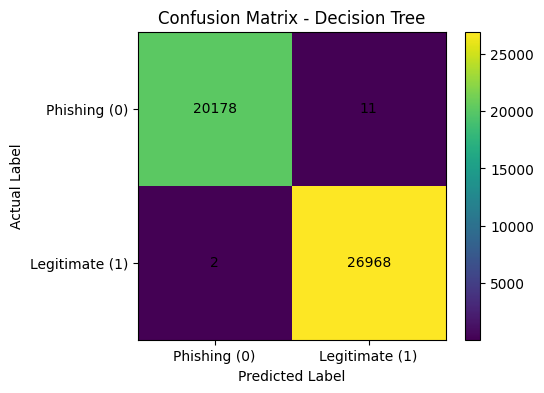

In [26]:
# Confusion matrix for the selected best model

best_model_name = "Decision Tree"
best_predictions = predictions[best_model_name]

cm = confusion_matrix(y_test, best_predictions)

print("Confusion Matrix for", best_model_name)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Phishing (0)", "Legitimate (1)"])
plt.yticks([0, 1], ["Phishing (0)", "Legitimate (1)"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [27]:
# Detailed classification report for the selected model

print("Classification Report for", best_model_name)
print(classification_report(y_test, best_predictions, target_names=["Phishing", "Legitimate"]))

Classification Report for Decision Tree
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



The evaluation results show that all three models performed strongly on the selected phishing website dataset. Logistic Regression, Decision Tree and Random Forest all achieved very high accuracy, precision, recall and F1-score. The Decision Tree model was selected as the final model because it achieved strong predictive performance while also having the shortest training time. The confusion matrix shows that the model correctly classified most phishing and legitimate websites, with only a small number of misclassifications. However, the results should not be interpreted as proof of perfect real-world performance, because the model was tested on this dataset only and may behave differently on new website data.

## 7. Final Model Saving

This section saves the selected final model so that it can be used later in the Streamlit web application. The selected feature names are also saved because the deployed application must use the same input features that were used during training.

In [28]:
# Final Model Saving

# Select the final trained model
final_model = trained_models["Decision Tree"]

# Save the final model
with open("model.pkl", "wb") as file:
    pickle.dump(final_model, file)

# Save the selected feature names
with open("selected_features.pkl", "wb") as file:
    pickle.dump(selected_features, file)

print("Final model saved as model.pkl")
print("Selected features saved as selected_features.pkl")

Final model saved as model.pkl
Selected features saved as selected_features.pkl


In [29]:
# Download saved files to local computer

from google.colab import files

files.download("model.pkl")
files.download("selected_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>